In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

c:\Users\Sangram Mishra\Desktop\ADK\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Sangram Mishra\AppData\Local\Temp\ipykernel_27960\1202363267.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [1]:
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain_ollama import ChatOllama
from langchain_core.documents import Document
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,NotRequired

c:\Users\Sangram Mishra\Desktop\ADK\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [5]:
embedings = HuggingFaceEmbeddings(model_name = "sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2198.14it/s]


In [6]:
client = Chroma(persist_directory="db/chroma")

In [100]:
retriver = client.as_retriever(search_type = "similarity",
    search_kwargs={"k": 3}
)

In [35]:
loader = PyPDFLoader("attn.pdf")
doc = loader.load()
spliter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = spliter.split_documents(doc)


In [57]:
retriver.invoke("what is attention")

[Document(id='dae9e9ff-7b7f-476b-a75b-6a70e26700dc', metadata={'description': 'Paper accepted and presented at the Neural Information Processing Systems Conference (http://nips.cc/)', 'total_pages': 11, 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On English-to-French translation, we outperform the p

In [81]:
class rag_state(TypedDict):
    question:str
    context: NotRequired[list[Document]]
    an: NotRequired[str]
    decision: str
    

In [ ]:
def retriever(state:rag_state):
    return {
        "context" : retriver.invoke(state["question"])
    }

In [9]:
llm = ChatOllama(model = "qwen3:8b")

In [101]:
rag_prompt = ChatPromptTemplate.from_template(
    """
You are an assistant answering questions using the
provided context.

Use only the information in the context.

If the answer is not present in the context,
say that you do not know.

Context:
{context}

Question:
{question}

Answer:
"""
)

In [60]:
def generate(state:rag_state):

    context = "\n\n".join(
        doc.page_content
        for doc in state["context"])
    msg = prompt.invoke({"context":context,"question":state["question"]})
    res = llm.invoke(msg)
    return {
        "an" : res.content
    }

In [61]:
class st_ot(BaseModel):
    relevance :bool = Field(description="return the output of retriver relevant or not")

In [62]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")



In [98]:
model = ChatOllama(model="nemotron-3-nano:4b")

In [64]:
model.invoke("what is the colour of sky")

AIMessage(content='The sky appears **blue** most of the time because sunlight passes through Earth’s atmosphere and scatters shorter‑wavelength blue wavelengths in all directions.  \n\n- **Daytime (midday):** Clear blue sky.  \n- **Sunrise & sunset:** The air is thin and the light is longer, so reds, oranges, and pinks dominate.  \n- **Highly polluted areas:** The scattered light can dominate and give the sky a slightly yellow, gray, or almost white hue.  \n- **When the Sun is hidden** (e.g., behind a cloud or during a meteor shower), the sky looks mostly white or black, reflecting surrounding objects rather than scattering blue light.  \n\nSo, under normal clear conditions the sky is **blue**.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-nano:4b', 'created_at': '2026-09-29T19:44:42.3744938Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11936383000, 'load_duration': 7521356300, 'prompt_eval_count': 22, 'prompt_eval_duration': 158836000, 'eval_count': 205, 

In [102]:
from langchain_core.prompts import ChatPromptTemplate

evaluator_prompt = ChatPromptTemplate.from_template(
    """
You are a context evaluation agent for a RAG system.

Your job is to determine whether the retrieved context
contains enough relevant information to answer the question.

Question:
{question}

Retrieved Context:
{context}

Rules:
- Return "yes" if the context contains enough relevant
  information to answer the question.
- Return "no" if the context is irrelevant or insufficient.
- Do not answer the user's question.

Return only:
yes
or
no
"""
)

In [93]:
def evaluate_context(state):

    context = "\n\n".join(
        doc.page_content
        for doc in state["context"]
    )

    messages = evaluator_prompt.invoke({
        "question": state["question"],
        "context": context
    })

    response = model.invoke(messages)

    decision = response.content.strip().lower()

    if "no" in decision:
        return "retrive"

    return "generate"

    

In [94]:
graph = StateGraph(rag_state)

In [95]:
graph.add_node("retrive",retrive)
graph.add_node("generate",generate)

graph.add_edge(START,"retrive")
graph.add_conditional_edges("retrive",evaluate_context)
graph.add_edge("generate", END)

In [96]:
APP = graph.compile()

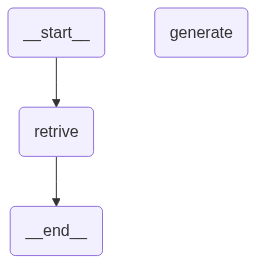

In [97]:
APP

In [71]:
APP.invoke({'question':"what is attention"})

{'question': 'what is attention',
 'context': [Document(id='dae9e9ff-7b7f-476b-a75b-6a70e26700dc', metadata={'lastpage': '6008', 'creator': 'PyPDF', 'creationdate': '', 'created': '2017', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On English-to-French translation, we outperform the previoussingle s

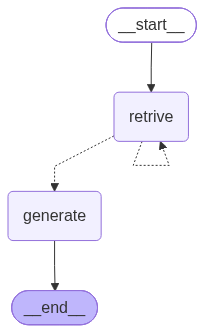

In [107]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# ============================================================
# 1. STATE
# ============================================================

class rag_state(TypedDict):
    question: str
    context: list
    answer: str


# ============================================================
# 2. RETRIEVER NODE
# ============================================================

def retrive(state):

    question = state["question"]

    # Your retriever
    docs = retriver.invoke(question)

    return {
        "context": docs
    }


# ============================================================
# 3. CONTEXT EVALUATOR / ROUTER
# ============================================================

def evaluate_context(state):

    # Convert retrieved documents into one string
    context = "\n\n".join(
        doc.page_content
        for doc in state["context"]
    )

    # Create evaluator prompt
    messages = evaluator_prompt.invoke({
        "question": state["question"],
        "context": context
    })

    # Ask LLM
    response = model.invoke(messages)

    # Convert response to lowercase
    decision = response.content.strip().lower()

    print("Evaluator decision:", decision)

    # Route to the appropriate node
    if decision == "yes":
        return "generate"
    else:
        return "retrive"


# ============================================================
# 4. GENERATE NODE
# ============================================================

def generate(state):

    context = "\n\n".join(
        doc.page_content
        for doc in state["context"]
    )

    messages = rag_prompt.invoke({
        "question": state["question"],
        "context": context
    })

    response = model.invoke(messages)

    return {
        "answer": response.content
    }


# ============================================================
# 5. CREATE GRAPH
# ============================================================

graph = StateGraph(rag_state)


# Add nodes
graph.add_node("retrive", retrive)
graph.add_node("generate", generate)


# ============================================================
# 6. EDGES
# ============================================================

# START → retrive
graph.add_edge(
    START,
    "retrive"
)


# retrive → evaluate_context → generate/retrive
graph.add_conditional_edges(
    "retrive",evaluate_context,{
            "generate": "generate",
            "retrive": "retrive"
        }
)


# generate → END
graph.add_edge(
    "generate",
    END
)


# ============================================================
# 7. COMPILE
# ============================================================

app = graph.compile()
app

In [112]:
from typing import TypedDict

from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END


# ============================================================
# 1. RAG STATE
# ============================================================

class rag_state(TypedDict):
    question: str
    context: list
    answer: str


# ============================================================
# 2. STRUCTURED OUTPUT SCHEMA
# ============================================================

class ContextEvaluation(BaseModel):
    relevant: bool = Field(
        description="True if the retrieved context is sufficient "
                    "to answer the question, otherwise False."
    )


# ============================================================
# 3. CONTEXT EVALUATOR AGENT
# ============================================================

evaluator_agent = create_agent(
    model=model,
    tools=[],

    system_prompt="""
You are a RAG context evaluator.

Your task is to determine whether the retrieved
context contains enough relevant information to
answer the user's question.

Set:

relevant = True

if the context contains sufficient information
to answer the question.

Set:

relevant = False

if the context is insufficient, irrelevant,
or does not contain enough information.

Do not answer the user's question.
Only evaluate the context.
""",

    response_format=ContextEvaluation
)


# ============================================================
# 4. RETRIEVE NODE
# ============================================================

def retrive(state: rag_state):

    question = state["question"]

    docs = retriver.invoke(question)

    print("\nRetrieved documents:", len(docs))

    return {
        "context": docs
    }


# ============================================================
# 5. CONTEXT EVALUATOR / ROUTER
# ============================================================

def evaluate_context(state: rag_state) -> str:

    # --------------------------------------------------------
    # Convert documents into text
    # --------------------------------------------------------

    context = "\n\n".join(
        doc.page_content
        for doc in state["context"]
    )

    # --------------------------------------------------------
    # Input for evaluator agent
    # --------------------------------------------------------

    evaluator_input = f"""
Question:

{state["question"]}


Retrieved Context:

{context}


Evaluate whether this context is sufficient
to answer the question.
"""

    # --------------------------------------------------------
    # Invoke agent
    # --------------------------------------------------------

    result = evaluator_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": evaluator_input
            }
        ]
    })

    # --------------------------------------------------------
    # GET STRUCTURED RESPONSE
    # --------------------------------------------------------

    evaluation = result["structured_response"]

    print("\nStructured evaluation:")
    print(evaluation)

    print("\nRelevant:")
    print(evaluation.relevant)

    # --------------------------------------------------------
    # ROUTING
    # --------------------------------------------------------

    if evaluation.relevant:
        return "generate"

    return "retrive"


# ============================================================
# 6. GENERATION PROMPT
# ============================================================

rag_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a helpful RAG assistant.

Answer the user's question using only the
provided context.

If the answer is not available in the context,
say that the information is not available
in the provided context.
"""
    ),

    (
        "human",
        """
Question:

{question}


Context:

{context}
"""
    )
])


# ============================================================
# 7. GENERATE NODE
# ============================================================

def generate(state: rag_state):

    context = "\n\n".join(
        doc.page_content
        for doc in state["context"]
    )

    messages = rag_prompt.invoke({
        "question": state["question"],
        "context": context
    })

    response = model.invoke(messages)

    return {
        "answer": response.content
    }


# ============================================================
# 8. CREATE LANGGRAPH
# ============================================================

graph = StateGraph(rag_state)


# ============================================================
# 9. ADD NODES
# ============================================================

graph.add_node(
    "retrive",
    retrive
)

graph.add_node(
    "generate",
    generate
)


# ============================================================
# 10. START → RETRIEVE
# ============================================================

graph.add_edge(
    START,
    "retrive"
)


# ============================================================
# 11. CONDITIONAL ROUTING
# ============================================================

graph.add_conditional_edges(
    "retrive",

    evaluate_context,

    {
        "generate": "generate",
        "retrive": "retrive"
    }
)


# ============================================================
# 12. GENERATE → END
# ============================================================

graph.add_edge(
    "generate",
    END
)


# ============================================================
# 13. COMPILE
# ============================================================

app = graph.compile()

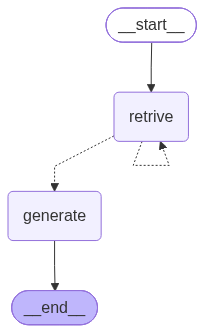

In [113]:
app

In [116]:
result = app.invoke({
    "question": "What is attention"
})

print(result)


Retrieved documents: 3

Structured evaluation:
relevant=True

Relevant:
True
{'question': 'What is attention', 'context': [Document(id='dae9e9ff-7b7f-476b-a75b-6a70e26700dc', metadata={'page_label': '3', 'description': 'Paper accepted and presented at the Neural Information Processing Systems Conference (http://nips.cc/)', 'page': 2, 'total_pages': 11, 'source': 'attn.pdf', 'publisher': 'Curran Associates, Inc.', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. O

In [117]:
type(result)

dict

In [118]:
result.keys()

dict_keys(['question', 'context', 'answer'])

In [119]:
result["answer"]

'An attention function is a mapping that takes a query and a set of key‑value pairs and produces an output as a weighted sum of those values.'